Decision Tree Accuracy: 96.36%


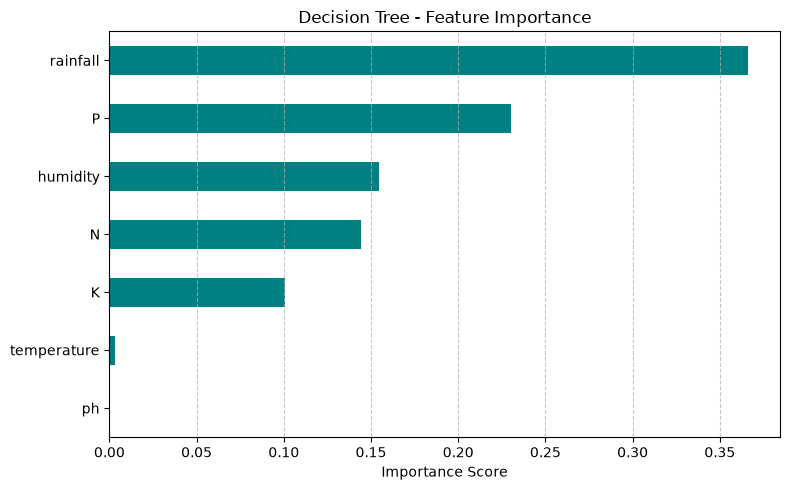

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1. โหลดข้อมูล
df = pd.read_csv('crop_fertilizer_recommendation_dataset.csv')
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
target = 'label'

X = df[features]
y = df[target]

# 2. แบ่งข้อมูล
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. เทรนโมเดล
model = DecisionTreeClassifier(criterion='gini', max_depth=10, random_state=42)
model.fit(X_train, y_train)

# 4. ประเมินผล
y_pred = model.predict(X_test)
print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

# 5. พล็อตกราฟ Feature Importance
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)
plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='teal')
plt.title('Decision Tree - Feature Importance')
plt.xlabel('Importance Score')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()